# 🌾 Crop Recommendation Model Training

This notebook was programmatically generated and aligned with the backend model specifications.

## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
print('Libraries loaded!')


Libraries loaded!


## 2. Load Dataset


In [2]:
df = pd.read_csv('../datasets/Crop_recommendation.csv')
print(f'Shape: {df.shape}')
df.head(5)


Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Preprocessing
We encode the target crop labels.


In [3]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].values
y = df['label'].values

le_crop = LabelEncoder()
y_encoded = le_crop.fit_transform(y)
print(f'Features shape: {X.shape}, unique crops: {len(le_crop.classes_)}')


Features shape: (2200, 7), unique crops: 22


## 4. Model Training
We train a Random Forest Classifier on the preprocessed features.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print(f'Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train)):.4f}')
print(f'Test Accuracy:  {accuracy_score(y_test, rf_model.predict(X_test)):.4f}')


Train Accuracy: 1.0000
Test Accuracy:  0.9955


## 5. Evaluation Metrics & Confusion Matrix Heatmap


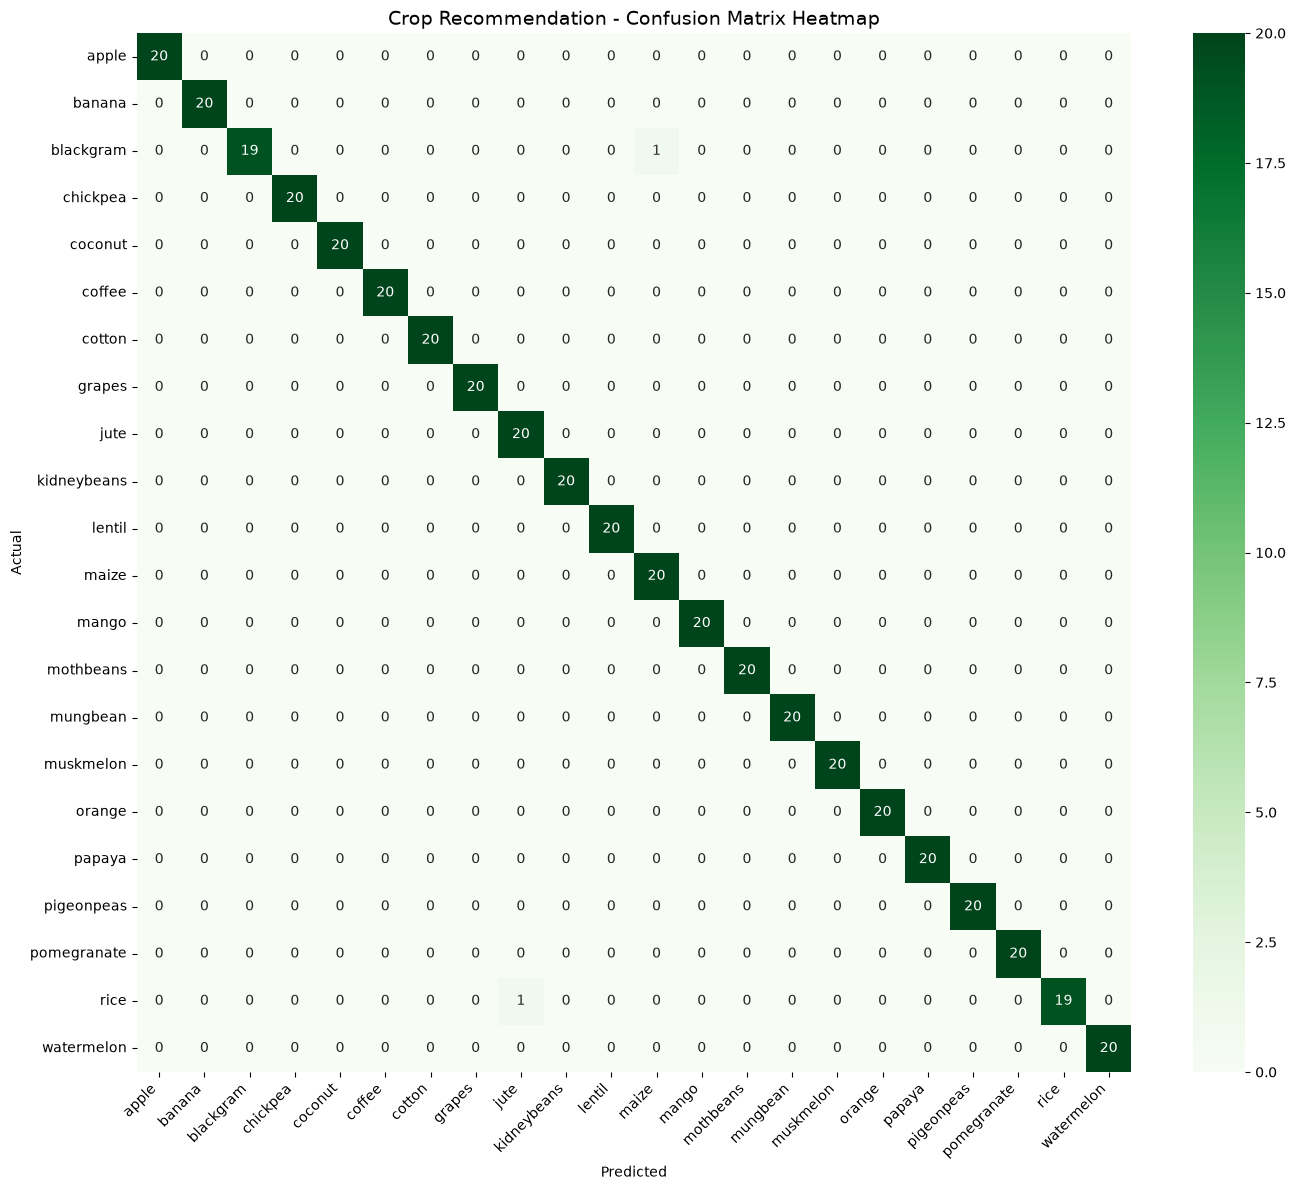

CROP CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, rf_model.predict(X_test))
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_crop.classes_, yticklabels=le_crop.classes_)
plt.title('Crop Recommendation - Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crop_confusion_matrix.png', dpi=150)
plt.show()

print("="*60)
print("CROP CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, rf_model.predict(X_test), target_names=le_crop.classes_))


## 6. Save Model Files


In [6]:
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/crop_recommendation.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('../../ml_models/crop_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_crop, f)
print('Successfully saved crop recommendation model!')


Successfully saved crop recommendation model!
